# Personal Information
Name: Aran Los

StudentID: 13530844

Submitted on: 23/03/2026

# Data Context
**In this section you should introduce the datasources and datasets which you will be working with. Explain where they are from as well as their domain. Give an overview of what the context of the data is. You should not spend more than 1 to 2 paragraphs here as the core information will be in the next section.**

I will be working with the CMOSE dataset, particularly their secondFeatures set, which has the OpenFace extracted features from their videos. The videos I talk about are short video clips of the faces of students as they are taking part in online lectures. CMOSE (as noted in their paper) contains 12,193 short video clip recordings of students in online learning environments. Each video clip is recorded at 25 fps, 412 x 234 resolution, and the lengths average 13.72 seconds. Furthermore, the dataset involves 102 participants (as said by the paper, however, I find 1 more individual which I further talk about below), consisting of individuals of different races and a male-to-female ratio of 0.65:1. CMOSE provides frame-level facial features extracted using OpenFace, including gaze direction vectors, head pose angles, eye-related features, and facial action unit intensities. The unaltered way I got (as it is in HuggingFace) is a 15.8 GB folder full of .csv files. Each .csv file is named in a specific way to describe which person, lecture session, and which clip of the full video it is about. The .csv files all hold OpenFace features as previously described. Furthermore, I have a different folder in which are JSON files that include the engagement label judged for each clip by one of a group of raters.

Also for context my RQ and sub-questions are as follows:
#### To what extent can robustness-oriented training methods mitigate performance disparities across behaviorally defined subgroups in gaze- and posture-based engagement models?

##### To what extent do gaze and posture features vary across behaviorally defined subgroups derived from observable visual patterns?

##### To what extent do baseline gaze- and posture-based engagement classifiers exhibit unequal error rates across these behavioral subgroups?

##### To what extent can fairness-aware training strategies reduce error disparities without substantially degrading overall predictive performance?

In [1]:
# Imports
import os
import numpy as np
import pandas as pd
import re
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
# styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# Data Description + Loading + Cleaning

To summarize the EDA and describe the (clean ) data, I will be using a dataset withholding 832,587 timesteps (which are mean-pooled between 5 frames). Each timestep has 721 features, including the metadata, quality flags, gaze features, pose features, AU intensity scores, AU presence scores, and the raw landmark columns. The data includes 12,197 unique clips (3 more than as noted in CMOSE's paper) and 103 participants (1 more than as said by the CMOSE paper). From the EDA, I found that the one extra person is an individual whose OpenFace features' confidence scores are 0, which means this person's data cannot be reliably used and should be removed from the dataset. This was most likely done by the authors of CMOSE as well. Furthermore, for the clip discrepancy, something like this was expected, as the data cleaning strategies used by them are not available in their paper so they will certainly be different here, which may have given rise to 4 extra clips. Subtracting the 35 clips associated with the 0 confidence individual puts the clip count in my dataset lower than CMOSE's at 12,162, which, again, considering the different cleaning strategies, is expected and fine. I will also note that the ratings folder had 22 more participants which don't appear in the .csv's (this is probably because something went wrong with the recording of those people). But the participants in both the CMOSE dataset and my cleaned dataset are equal, which implies the data is good to use. Additionally, there was a low amount of NA labels in the ratings (2.37%) all of which were dropped for the future. Looking into the comments on why they were marked NA, I found many with comments detailing that the participant was not on screen.

#### Key Findings
The first key finding in the data is has a low rater disagreement rate of 31.56%. Most of these disagreements were predominantly 2v1 splits rather than 50/50, meaning they still had a clear majority direction. This is expected as engagement is subjective and harder to recognize. The CMOSE paper itself acknowledges this by using multiple raters and taking care to train them with psychological guidance. With this, I decided to use majority vote aggregation to give principled resolution to these disagreements whilst retaining the direction most raters agreed on. These agreement rate measures were also kept and analyzed throughout the EDA. Next key finding in the database is that there is a high class imbalance between disengaged and engaged, with 19.9% of clips being labelled disengaged and 80.1% being engaged. This means that a baseline model guessing everything as engaged has an accuracy of 80%, which my model would need to beat. This class imbalance, however, also supports my focus on reweighting in the training process, making it a definite part of my methodology. Furthermore, the dataset I use has a low percentage of timesteps (since I downsampled the data to 5Hz) with a low OpenFace confidence score (for the  confidence threshold, I use > 0.8 as high confidence, as it is the standard OpenFace threshold). The percentage of timesteps with low confidence is 4.15%. Regarding this, I am deciding to keep this data rather than dropping it, as the lower confidence by itself (at the small amount that it exists in the data) can be used as a feature. Since the confidence refers to how well OpenFace was able to track the face, low confidence could mean moments in which the individual was moving or looked away, which can also help in detecting engagement. However, the 2.79% of cases with failed tracking will be removed. Another key finding is on outlier detection. In detecting outliers, a much higher proportion of outliers came from the engaged class (77.2%). If the outliers were random tracking noise, it would be expected to be the same; however, there is a clear class imbalance. The explanation for this is that these detected "outliers" are most likely simply extreme facial movements like smiling, head nodding, raising eyebrows, etc. and this illustrates that in the data, more extreme facial movements are correlated to engagement. Moving forward, I will decide to flag and keep these outliers for future error analysis. Finally, through Pearson correlation coefficients, I found the top 5 features most correlated to engagement to be AU12_r, AU06_r, gaze_1_z, gaze_0_z, and AU07_r. These will be kept in mind and further explored during modelling.

Overall, through everything I have learned about the data, I can confirm that it is alligned with my methodology. There are countless other small discoveries I have made on the data in my EDA below (it is under the title "Data Analysis"), which is separated into sections for easier viewing.

In [2]:
# from huggingface_hub import snapshot_download
# snapshot_download(repo_id="cwuau/CMOSE", repo_type="dataset", local_dir=r"C:\Users\super\Desktop\exploratory-data-analysis")

In [3]:
##########################################
# Config
##########################################
CSV_FOLDER     = r"C:\Users\super\Desktop\exploratory-data-analysis\CMOSE\secondFeature\secondFeature"
RATINGS_FOLDER = r"C:\Users\super\Desktop\exploratory-data-analysis\CMOSE\ratings"

ORIGINAL_FPS = 25
TARGET_FPS   = 5
WINDOW_SIZE  = ORIGINAL_FPS // TARGET_FPS  # window is 5 frames

engagement_map = {
    "Highly Engage":    1,
    "Engage":           1,
    "Disengage":        0,
    "Highly Disengage": 0,
    "NA":               None
} # mapping to make engagement labels binary

In [4]:
##########################################
# Load all CSV files containing OpenFace feats (this one takes a while to run)
##########################################
print("Loading CSVs...")
dfs = []

for filename in os.listdir(CSV_FOLDER):
    if not filename.endswith(".csv"):
        continue

    match = re.match(r"video(\d+)_(\d+)_person(\d+)\.csv", filename)
    if not match:
        print(f"  Skipping unrecognised file: {filename}")
        continue

    session, clip_idx, person_num = match.groups()

    df = pd.read_csv(os.path.join(CSV_FOLDER, filename))
    df["session"]        = int(session) # lecture session
    df["clip_idx"]       = int(clip_idx) # clip id
    df["person"]         = f"person{person_num}" # person number per session
    df["participant_id"] = f"{session}_person{person_num}"  # new unique key because some people across different sessions share person_num
    df["clip_id"]        = filename.replace(".csv", "")

    dfs.append(df)

all_clips = pd.concat(dfs, ignore_index=True)
print(f"  Loaded {len(dfs)} CSV files → {len(all_clips):,} total frames")
print(f"  Unique persons (raw):                 {all_clips['person'].nunique()}")
print(f"  Unique participants (using new key):  {all_clips['participant_id'].nunique()}")

total_values  = all_clips.size
missing_count = all_clips.isnull().sum().sum()
print(f"\n── Missing values in all_clips ─────────")
print(f"  Total missing values: {missing_count:,} ({missing_count / total_values:.2%} of all values)")

missing_per_col = all_clips.isnull().sum()
missing_per_col = missing_per_col[missing_per_col > 0].sort_values(ascending=False)
if len(missing_per_col) == 0:
    print("  No missing values found in any column.")
else:
    print(f"  Columns with missing values:")
    for col, count in missing_per_col.items():
        print(f"    {col}: {count:,} ({count / len(all_clips):.2%})")

Loading CSVs...
  Loaded 12197 CSV files → 4,139,312 total frames
  Unique persons (raw):                 30
  Unique participants (using new key):  103

── Missing values in all_clips ─────────
  Total missing values: 0 (0.00% of all values)
  No missing values found in any column.


In [5]:
##########################################
# Load all rating JSONs (These JSONs have the labels)
##########################################
print("\nLoading ratings...")
rating_records = []

for filename in os.listdir(RATINGS_FOLDER):
    if not filename.endswith(".json"):
        continue

    match = re.match(r"video_(\d+)-rater(\w+)\.json", filename)
    if not match:
        print(f"  Skipping unrecognised file: {filename}")
        continue

    session, rater = match.groups()

    with open(os.path.join(RATINGS_FOLDER, filename)) as f:
        data = json.load(f)

    for interval in data:
        for person in interval["people"]:
            category = person["category"].strip()

            if not category:
                continue

            rating_records.append({
                "session":        int(session),
                "rater":          rater, # rater id
                "clip_idx":       interval["clipIdx"],
                "person":         person["name"],
                "participant_id": f"{int(session)}_{person['name']}",
                "engagement":     engagement_map.get(category) # binary engagement label
            })

ratings_df = pd.DataFrame(rating_records)

total_ratings = len(ratings_df)
na_count      = ratings_df["engagement"].isna().sum()
print(f"\n── NA labels in ratings_df ─────────────")
print(f"  NA labels:      {na_count:,} ({na_count / total_ratings:.2%})")
print(f"  Valid labels:   {total_ratings - na_count:,} ({(total_ratings - na_count) / total_ratings:.2%})")

ratings_df = ratings_df.dropna(subset=["engagement"]) # drop NA-labelled rows

print(f"\n── General ratings_df Overview ─────────────")
print(f"  Loaded {len(ratings_df):,} ratings")
print(f"  Unique participants in ratings: {ratings_df['participant_id'].nunique()}")
print(f"  Label distribution:\n{ratings_df['engagement'].value_counts()}")


Loading ratings...

── NA labels in ratings_df ─────────────
  NA labels:      1,040 (2.37%)
  Valid labels:   42,830 (97.63%)

── General ratings_df Overview ─────────────
  Loaded 42,830 ratings
  Unique participants in ratings: 125
  Label distribution:
engagement
1.0    32601
0.0    10229
Name: count, dtype: int64


In [6]:
##########################################
# Aggregate ratings across raters
##########################################
print("\nAggregating across raters...")

labels_df = (
    ratings_df
    .groupby(["session", "clip_idx", "person", "participant_id"])["engagement"]
    .agg(
        engagement_mean     = "mean",
        engagement_majority = lambda x: int(x.mean() >= 0.5), # aggregating labels by majority
        rater_count         = "count",
        rater_agreement     = lambda x: (x == x.mode().iloc[0]).all() if len(x.mode()) > 0 else False # rater agreement calculated for analysis
    ) 
    .reset_index()
)

labels_df["engagement"]     = labels_df["engagement_majority"]
labels_df["person"]         = labels_df["person"].astype(str)
labels_df["participant_id"] = labels_df["participant_id"].astype(str)

print(f"  Unique clip/person combinations: {len(labels_df):,}")
print(f"  Unique participants in labels:   {labels_df['participant_id'].nunique()}")
print(f"  Rater agreement rate: {labels_df['rater_agreement'].mean():.2%}")
print(f"  Final label distribution:\n{labels_df['engagement'].value_counts()}")


Aggregating across raters...
  Unique clip/person combinations: 14,786
  Unique participants in labels:   125
  Rater agreement rate: 68.44%
  Final label distribution:
engagement
1    11711
0     3075
Name: count, dtype: int64


In [7]:
# Quick analysis on label distributions:

# how the raw ratings are distributed per class before aggregation
print("Raw ratings per class:")
print(ratings_df["engagement"].value_counts(normalize=True).round(3))

# avg number of raters per clip, broken down by final label
print("\nAvg raters per clip/person by final label:")
print(labels_df.groupby("engagement")["rater_count"].mean().round(2))

# distribution of rater counts
print("\nRater count distribution:")
print(labels_df["rater_count"].value_counts().sort_index())

Raw ratings per class:
engagement
1.0    0.761
0.0    0.239
Name: proportion, dtype: float64

Avg raters per clip/person by final label:
engagement
0    2.80
1    2.92
Name: rater_count, dtype: float64

Rater count distribution:
rater_count
1      929
2      350
3    12827
4      680
Name: count, dtype: int64


In [8]:
##########################################
# Downsample features to 5Hz via mean pooling (too many frames otherwise, was already getting memory issues)
##########################################
print("\nDownsampling to 5Hz...")

feature_cols = [c for c in all_clips.columns
                if c not in ["session", "clip_idx", "person", "participant_id",
                             "clip_id", "frame", "timestamp"]] # picking out the actual feat columns, not metadata columns

downsampled_clips = []

for (session, clip_idx, person, participant_id), group in all_clips.groupby(
        ["session", "clip_idx", "person", "participant_id"]):

    group = group.sort_values("frame").reset_index(drop=True)

    group["window"] = group.index // WINDOW_SIZE # assign each frame to a non-overlapping window

    pooled = group.groupby("window")[feature_cols].mean().reset_index(drop=True) # mean pool feats within each window

    # bring back metadata
    pooled["session"]        = session
    pooled["clip_idx"]       = clip_idx
    pooled["person"]         = person
    pooled["participant_id"] = participant_id
    pooled["clip_id"]        = group["clip_id"].iloc[0]
    pooled["timestep"]       = pooled.index

    downsampled_clips.append(pooled)

all_clips_downsampled = pd.concat(downsampled_clips, ignore_index=True)

all_clips_downsampled["person"]         = all_clips_downsampled["person"].astype(str)
all_clips_downsampled["participant_id"] = all_clips_downsampled["participant_id"].astype(str)

print(f"  Before: {len(all_clips):,} frames")
print(f"  After:  {len(all_clips_downsampled):,} timesteps")
print(f"  Avg timesteps per clip: {all_clips_downsampled.groupby('clip_id').size().mean():.1f}")
print(f"  Memory usage: {all_clips_downsampled.memory_usage(deep=True).sum() / 1e9:.2f} GB")


Downsampling to 5Hz...
  Before: 4,139,312 frames
  After:  832,587 timesteps
  Avg timesteps per clip: 68.3
  Memory usage: 4.91 GB


In [9]:
##########################################
# Merge the OpenFace feats df with the labels df
##########################################
print("\nMerging features with labels...")

final_df = all_clips_downsampled.merge(
    labels_df[["session", "clip_idx", "person", "participant_id",
               "engagement", "rater_count", "rater_agreement"]],
    on=["session", "clip_idx", "person", "participant_id"],
    how="left"
)

# Drop unlabelled rows
final_df = final_df.dropna(subset=["engagement"])
final_df["engagement"] = final_df["engagement"].astype(int)

print(f"  Final shape: {final_df.shape}")
print(f"  Labelled timesteps: {len(final_df):,}")
print(f"  Label distribution:\n{final_df['engagement'].value_counts()}")


Merging features with labels...
  Final shape: (832587, 721)
  Labelled timesteps: 832,587
  Label distribution:
engagement
1    664889
0    167698
Name: count, dtype: int64


In [10]:
##########################################
# Final sanity checks
##########################################
print("\nSanity checks...")

print(f"  Unique sessions:      {final_df['session'].nunique()}")
print(f"  Unique persons (raw): {final_df['person'].nunique()}")
print(f"  Unique participants:  {final_df['participant_id'].nunique()}")
print(f"  Unique clips:         {final_df['clip_id'].nunique():,}")
print(f"  Avg timesteps per clip:          {final_df.groupby('clip_id').size().mean():.1f}")
print(f"  Clips with low rater agreement:  {(labels_df['rater_agreement'] == False).sum()}")
print(f"  Mean confidence score:           {final_df['confidence'].mean():.3f}")
print(f"  Low confidence timesteps (<0.8): {(final_df['confidence'] < 0.8).mean():.2%}")


Sanity checks...
  Unique sessions:      9
  Unique persons (raw): 30
  Unique participants:  103
  Unique clips:         12,197
  Avg timesteps per clip:          68.3
  Clips with low rater agreement:  4667
  Mean confidence score:           0.926
  Low confidence timesteps (<0.8): 4.15%


In [11]:
# CSV participants (as in the ones with OpenFace feats)
csv_participants = set(all_clips["participant_id"].unique())

# JSON participants (the ones in the ratings)
ratings_participants = set(ratings_df["participant_id"].unique())

# participants that survived the merge
in_both = csv_participants & ratings_participants

# participants with features but no label
only_in_csv = csv_participants - ratings_participants

# participants with labels but no features
only_in_ratings = ratings_participants - csv_participants

print(f"Participants in CSVs:       {len(csv_participants)}")
print(f"Participants in ratings:    {len(ratings_participants)}")
print(f"Participants in both:       {len(in_both)}")
print(f"Only in CSVs (no labels):   {len(only_in_csv)}")
print(f"Only in ratings (no CSVs):  {len(only_in_ratings)}")

print(f"\nParticipants only in ratings (no feature file):")
print(sorted(only_in_ratings))

print(f"\nParticipants only in CSVs (no labels):")
print(sorted(only_in_csv))

Participants in CSVs:       103
Participants in ratings:    125
Participants in both:       103
Only in CSVs (no labels):   0
Only in ratings (no CSVs):  22

Participants only in ratings (no feature file):
['10_person29', '10_person31', '10_person38', '10_person39', '10_person44', '16_person9', '19_person1', '1_person1', '1_person6', '1_person7', '3_person0', '3_person1', '3_person10', '3_person12', '3_person13', '3_person2', '3_person3', '3_person4', '3_person5', '3_person7', '3_person8', '3_person9']

Participants only in CSVs (no labels):
[]


In [12]:
# number of clips total vs low agreement
total_clips = len(labels_df)
low_agreement = (labels_df["rater_agreement"] == False).sum()
print(f"Low agreement clips: {low_agreement} / {total_clips} ({low_agreement/total_clips:.2%})")

# split of raters in disagreed clips
disagreed = labels_df[labels_df["rater_agreement"] == False]
print(f"\nMean engagement score on disagreed clips (0.5 = perfectly split):")
print(disagreed["engagement_mean"].describe())

# perfect rating split clips
perfectly_split = (disagreed["engagement_mean"] == 0.5).sum()
print(f"\nPerfectly split clips (50/50 raters): {perfectly_split}")

# disagreements by session
print("\nLow agreement clips by session:")
print(disagreed.merge(
    labels_df[["session", "clip_idx", "person"]],
    on=["session", "clip_idx", "person"],
    how="left"
)["session"].value_counts())

Low agreement clips: 4667 / 14786 (31.56%)

Mean engagement score on disagreed clips (0.5 = perfectly split):
count    4667.000000
mean        0.548336
std         0.160956
min         0.250000
25%         0.333333
50%         0.666667
75%         0.666667
max         0.750000
Name: engagement_mean, dtype: float64

Perfectly split clips (50/50 raters): 189

Low agreement clips by session:
session
6     904
10    868
7     790
18    396
14    350
3     345
5     344
15    230
1     226
16    199
19     15
Name: count, dtype: int64


# Data Analysis

In [13]:
#═══════════════════════════════════════════════════════
# SECTION 1: CORPUS OVERVIEW (With the clean data)
#═══════════════════════════════════════════════════════
print("═" * 60)
print("SECTION 1: CORPUS OVERVIEW")
print("═" * 60)

print(f"\n── Shape ───────────────────────────────")
print(f"Timesteps (instances): {len(final_df):,}")
print(f"Features (columns):    {final_df.shape[1]}")
print(f"Unique clips:          {final_df['clip_id'].nunique():,}")
print(f"Unique participants:   {final_df['participant_id'].nunique()}")
print(f"Unique sessions:       {final_df['session'].nunique()}")

print(f"\n── Variable Types ──────────────────────")
type_counts = final_df.dtypes.value_counts()
print(type_counts)

meta_cols  = ["session", "clip_idx", "person", "participant_id",
              "clip_id", "timestep"]
qual_cols  = ["confidence", "success"]
gaze_cols  = [c for c in final_df.columns if "gaze" in c]
pose_cols  = [c for c in final_df.columns if "pose" in c]
au_r_cols  = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_r")]
au_c_cols  = [c for c in final_df.columns if c.startswith("AU") and c.endswith("_c")]
lmk_cols   = [c for c in final_df.columns if any(c.startswith(p)
               for p in ["x_", "y_", "X_", "Y_", "Z_", "eye_lmk", "p_"])]
label_cols = ["engagement"]

print(f"\n── Feature Groups ──────────────────────")
print(f"Metadata columns:          {len(meta_cols)}")
print(f"Quality flags:             {len(qual_cols)}") # quality flags are the confidence scores of those clips' OpenFace features
print(f"Gaze features:             {len(gaze_cols)}")
print(f"Pose features:             {len(pose_cols)}")
print(f"AU intensity (_r):         {len(au_r_cols)}") # AU is action unit, basically represents strength of particular facial muscle activation
print(f"AU presence (_c):          {len(au_c_cols)}") # AU presence is the visibility of a particular AU on the face
print(f"Landmark columns:          {len(lmk_cols)}") # raw facial keypoint coordinates output by OpenFace

print(f"\n── Missing Values ──────────────────────")
missing = final_df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) == 0:
    print("No missing values found.")
else:
    print(missing)
    print(f"\nTotal missing: {missing.sum():,} ({missing.sum() / final_df.size:.2%} of all values)")

════════════════════════════════════════════════════════════
SECTION 1: CORPUS OVERVIEW
════════════════════════════════════════════════════════════

── Shape ───────────────────────────────
Timesteps (instances): 832,587
Features (columns):    721
Unique clips:          12,197
Unique participants:   103
Unique sessions:       9

── Variable Types ──────────────────────
float64    712
int64        5
object       3
bool         1
Name: count, dtype: int64

── Feature Groups ──────────────────────
Metadata columns:          6
Quality flags:             2
Gaze features:             8
Pose features:             6
AU intensity (_r):         17
AU presence (_c):          18
Landmark columns:          660

── Missing Values ──────────────────────
No missing values found.



════════════════════════════════════════════════════════════
SECTION 2: CLIP-LEVEL STATISTICS
════════════════════════════════════════════════════════════

── Timesteps per clip ──────────────────
count    12197.00
mean        68.26
std         23.61
min          3.00
25%         52.00
50%         63.00
75%         81.00
max        320.00
Name: n_timesteps, dtype: float64


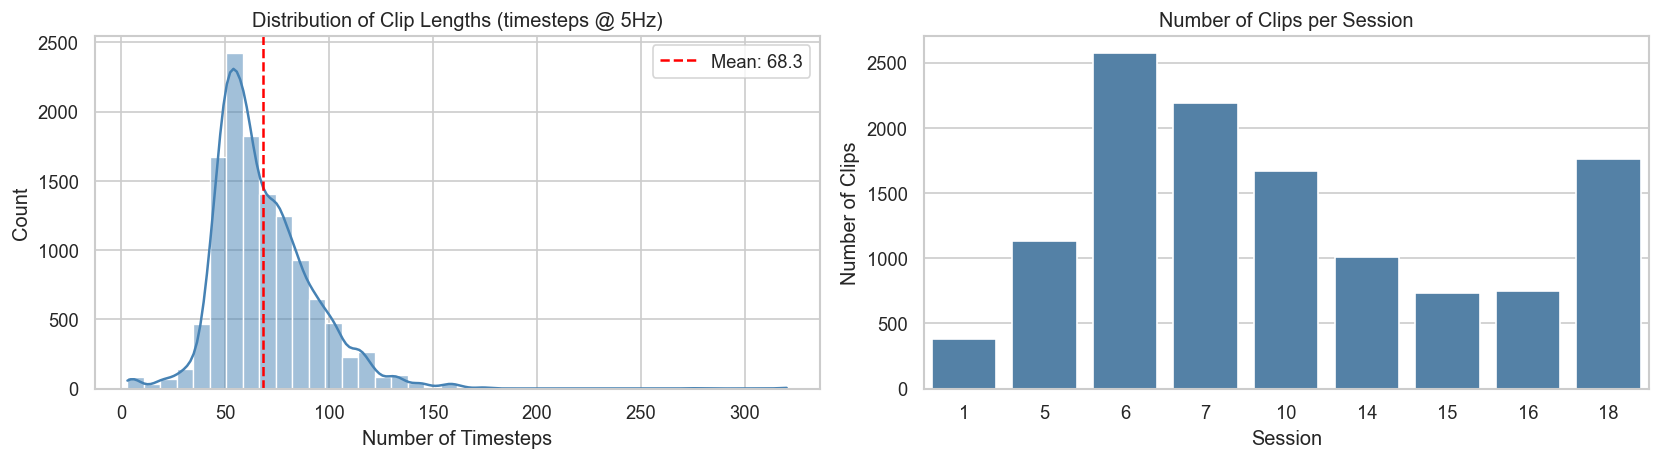


── Clips per participant ────────────────
count    103.00
mean     118.42
std       80.56
min        1.00
25%       55.50
50%       85.00
75%      180.00
max      285.00
dtype: float64


In [14]:
#═══════════════════════════════════════════════════════
# SECTION 2: CLIP-LEVEL STATISTICS
#═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 2: CLIP-LEVEL STATISTICS")
print("═" * 60)

clip_stats = final_df.groupby("clip_id").agg(
    session        = ("session", "first"),
    participant_id = ("participant_id", "first"),
    n_timesteps    = ("timestep", "count"),
    engagement     = ("engagement", "first")
).reset_index()

print(f"\n── Timesteps per clip ──────────────────")
print(clip_stats["n_timesteps"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(clip_stats["n_timesteps"], bins=40, kde=True,
             ax=axes[0], color="steelblue")
axes[0].axvline(clip_stats["n_timesteps"].mean(), color="red",
                linestyle="--",
                label=f'Mean: {clip_stats["n_timesteps"].mean():.1f}')
axes[0].set_title("Distribution of Clip Lengths (timesteps @ 5Hz)")
axes[0].set_xlabel("Number of Timesteps")
axes[0].legend()

clips_per_session = clip_stats.groupby("session").size().reset_index(name="n_clips")
sns.barplot(data=clips_per_session, x="session", y="n_clips",
            ax=axes[1], color="steelblue")
axes[1].set_title("Number of Clips per Session")
axes[1].set_xlabel("Session")
axes[1].set_ylabel("Number of Clips")

plt.tight_layout()
# plt.savefig("clip_statistics.png", bbox_inches="tight")
plt.show()

print(f"\n── Clips per participant ────────────────")
print(clip_stats.groupby("participant_id").size().describe().round(2))


════════════════════════════════════════════════════════════
SECTION 3: CLASS BALANCE & BASELINE
════════════════════════════════════════════════════════════

── Timestep level ──────────────────────
             count  proportion
engagement                    
1           664889      0.7986
0           167698      0.2014

── Clip level ──────────────────────────
            count  proportion
engagement                   
1            9764      0.8005
0            2433      0.1995

Baseline accuracy (majority class): 80.05%
 Any model must exceed 80.05% to be useful


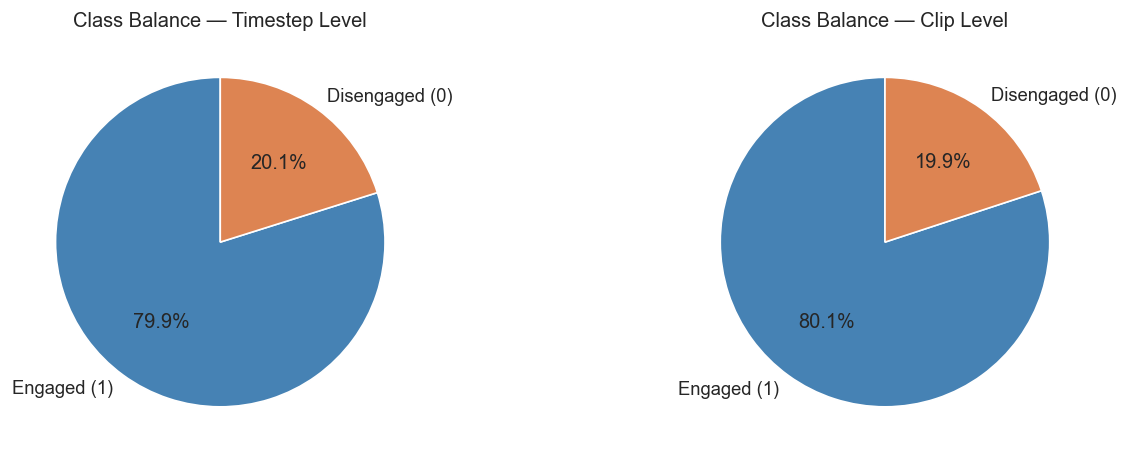

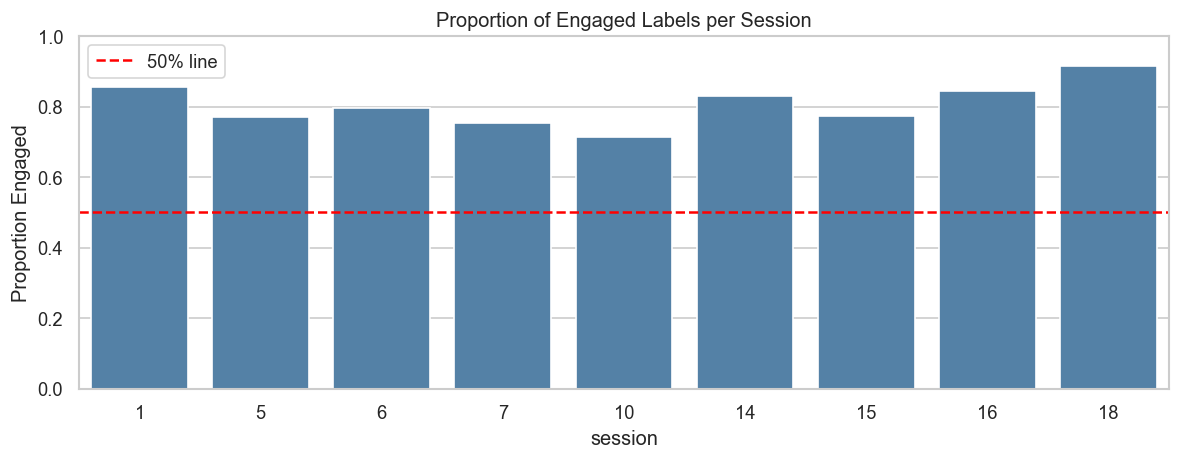

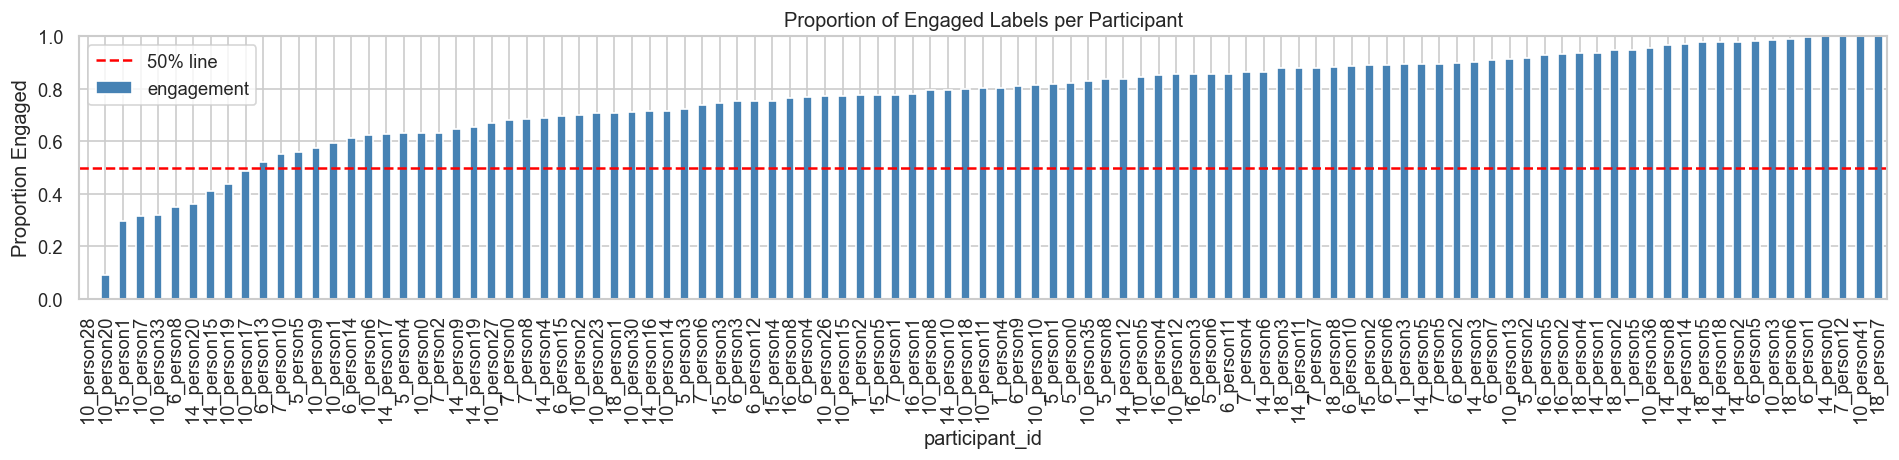

In [15]:
# ═══════════════════════════════════════════════════════
# SECTION 3: CLASS BALANCE (BASELINE)
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 3: CLASS BALANCE & BASELINE")
print("═" * 60)

ts_counts = final_df["engagement"].value_counts()
ts_pct    = final_df["engagement"].value_counts(normalize=True)

clip_counts = clip_stats["engagement"].value_counts()
clip_pct    = clip_stats["engagement"].value_counts(normalize=True)

print(f"\n── Timestep level ──────────────────────")
print(pd.DataFrame({"count": ts_counts, "proportion": ts_pct.round(4)}))

print(f"\n── Clip level ──────────────────────────")
print(pd.DataFrame({"count": clip_counts, "proportion": clip_pct.round(4)}))

majority_class = clip_pct.max()
print(f"\nBaseline accuracy (majority class): {majority_class:.2%}")
print(f" Any model must exceed {majority_class:.2%} to be useful")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(ts_counts, labels=["Engaged (1)", "Disengaged (0)"],
            autopct="%1.1f%%", colors=["steelblue", "#DD8452"], startangle=90)
axes[0].set_title("Class Balance — Timestep Level")

axes[1].pie(clip_counts, labels=["Engaged (1)", "Disengaged (0)"],
            autopct="%1.1f%%", colors=["steelblue", "#DD8452"], startangle=90)
axes[1].set_title("Class Balance — Clip Level")

plt.tight_layout()
# plt.savefig("class_balance.png", bbox_inches="tight")
plt.show()

# class balance per session
session_balance = final_df.groupby("session")["engagement"].mean().reset_index()
session_balance.columns = ["session", "prop_engaged"]

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=session_balance, x="session", y="prop_engaged",
            ax=ax, color="steelblue")
ax.axhline(0.5, color="red", linestyle="--", label="50% line")
ax.set_title("Proportion of Engaged Labels per Session")
ax.set_ylabel("Proportion Engaged")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
# plt.savefig("class_balance_by_session.png", bbox_inches="tight")
plt.show()

# class balance per participant
participant_balance = final_df.groupby("participant_id")["engagement"].mean().sort_values()

fig, ax = plt.subplots(figsize=(16, 4))
participant_balance.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(0.5, color="red", linestyle="--", label="50% line")
ax.set_title("Proportion of Engaged Labels per Participant")
ax.set_ylabel("Proportion Engaged")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
# plt.savefig("class_balance_by_participant.png", bbox_inches="tight")
plt.show()


════════════════════════════════════════════════════════════
SECTION 4: OPENFACE TRACKING QUALITY
════════════════════════════════════════════════════════════

── Confidence scores ───────────────────
count    832587.000
mean          0.926
std           0.161
min           0.000
25%           0.930
50%           0.980
75%           0.980
max           0.980
Name: confidence, dtype: float64
Low confidence (<0.8): 4.15%
Failed tracking (success=0): 2.79%


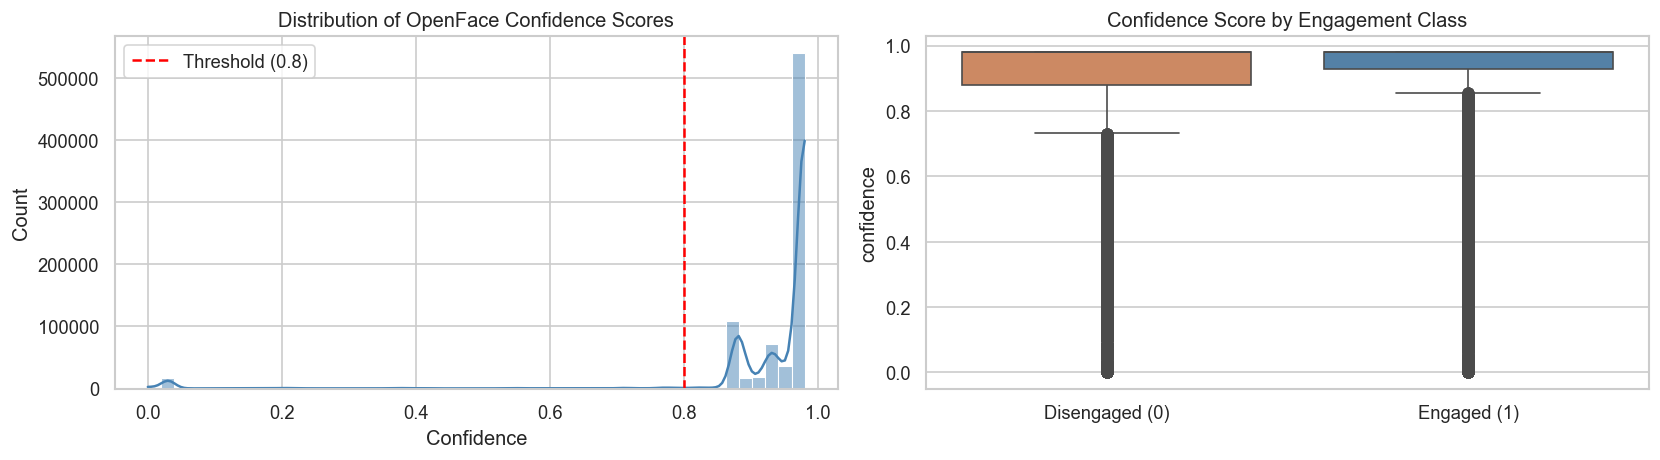

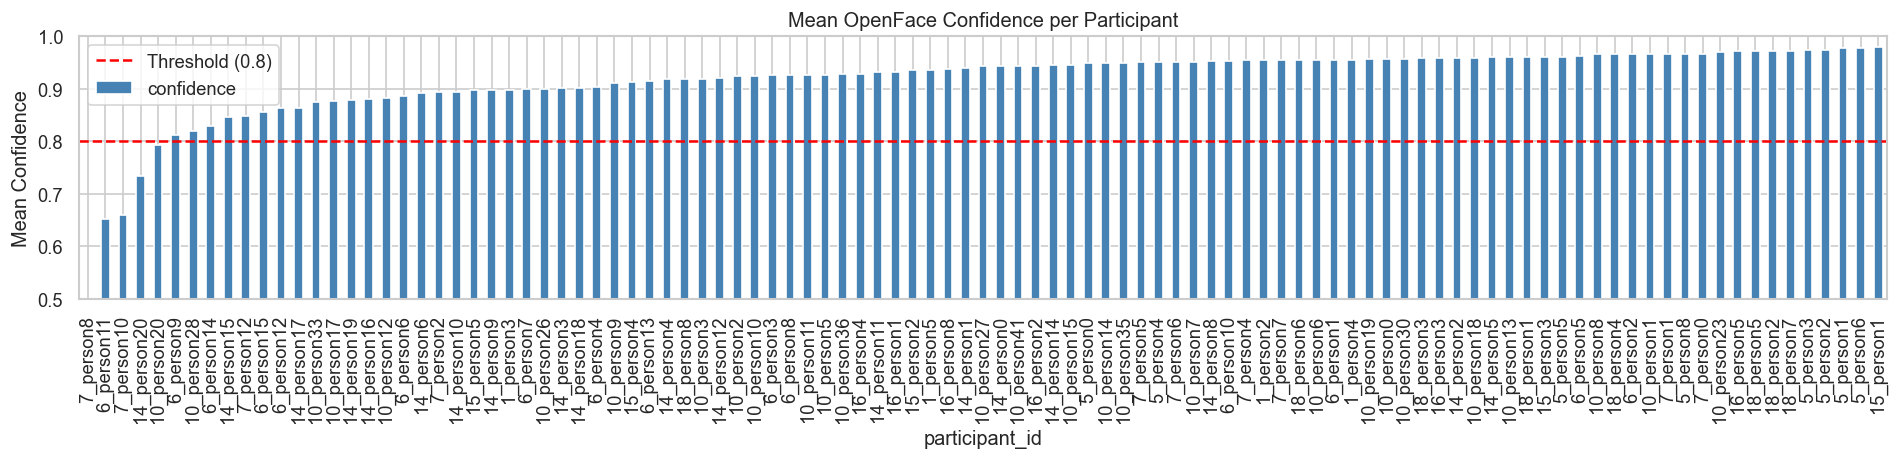

In [16]:
# ═══════════════════════════════════════════════════════
# SECTION 4: TRACKING QUALITY
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 4: OPENFACE TRACKING QUALITY")
print("═" * 60)

print(f"\n── Confidence scores ───────────────────")
print(final_df["confidence"].describe().round(3))
print(f"Low confidence (<0.8): {(final_df['confidence'] < 0.8).mean():.2%}")
print(f"Failed tracking (success=0): {(final_df['success'] == 0).mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(final_df["confidence"], bins=50, kde=True,
             ax=axes[0], color="steelblue")
axes[0].axvline(0.8, color="red", linestyle="--", label="Threshold (0.8)")
axes[0].set_title("Distribution of OpenFace Confidence Scores")
axes[0].set_xlabel("Confidence")
axes[0].legend()

sns.boxplot(data=final_df, x="engagement", y="confidence",
            ax=axes[1], palette=["#DD8452", "steelblue"])
axes[1].set_title("Confidence Score by Engagement Class")
axes[1].set_xticklabels(["Disengaged (0)", "Engaged (1)"])
axes[1].set_xlabel("")

plt.tight_layout()
# plt.savefig("tracking_quality.png", bbox_inches="tight")
plt.show()

# confidence per participant (gives insight into the fairness of data, any biases)
conf_by_participant = (final_df.groupby("participant_id")["confidence"]
                       .mean().sort_values())

fig, ax = plt.subplots(figsize=(16, 4))
conf_by_participant.plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(0.8, color="red", linestyle="--", label="Threshold (0.8)")
ax.set_title("Mean OpenFace Confidence per Participant")
ax.set_ylabel("Mean Confidence")
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
# plt.savefig("confidence_by_participant.png", bbox_inches="tight")
plt.show()


════════════════════════════════════════════════════════════
SECTION 5: UNIVARIATE FEATURE ANALYSIS
════════════════════════════════════════════════════════════

── AU Intensity (_r) summary ───────────
         mean    std  min    max
AU01_r  0.139  0.287  0.0  5.000
AU02_r  0.072  0.199  0.0  5.000
AU04_r  0.476  0.647  0.0  4.758
AU05_r  0.053  0.153  0.0  5.000
AU06_r  0.232  0.462  0.0  4.274
AU07_r  0.382  0.652  0.0  5.000
AU09_r  0.057  0.153  0.0  4.268
AU10_r  0.359  0.542  0.0  4.996
AU12_r  0.340  0.548  0.0  4.372
AU14_r  0.525  0.662  0.0  5.000
AU15_r  0.148  0.342  0.0  5.000
AU17_r  0.413  0.516  0.0  5.000
AU20_r  0.096  0.228  0.0  5.000
AU23_r  0.086  0.215  0.0  5.000
AU25_r  0.322  0.473  0.0  5.000
AU26_r  0.335  0.474  0.0  5.000
AU45_r  0.160  0.301  0.0  4.530

── AU Presence (_c) activation rates ───
AU05_c    0.607
AU14_c    0.500
AU10_c    0.304
AU04_c    0.300
AU07_c    0.289
AU23_c    0.228
AU17_c    0.200
AU12_c    0.199
AU06_c    0.174
AU45_c    0.153


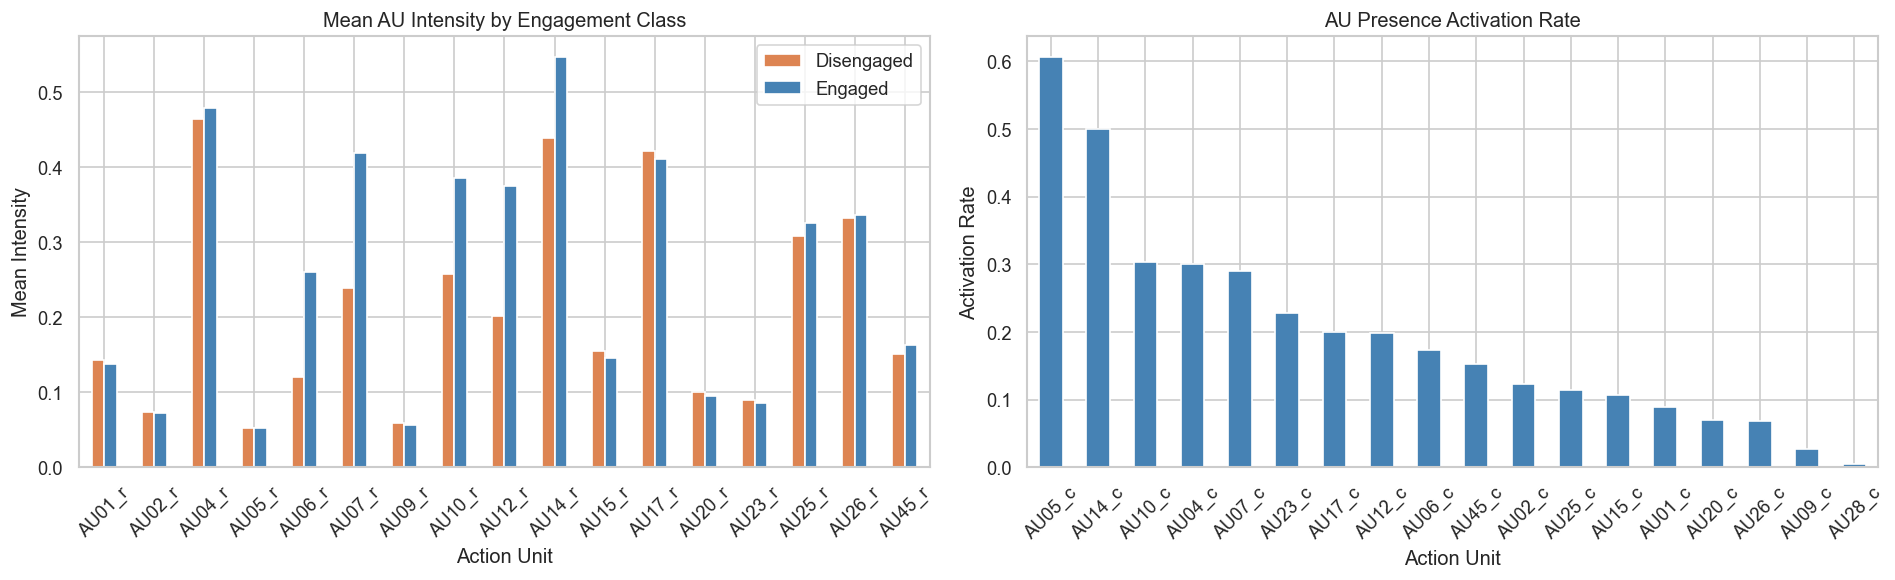


── Gaze feature summary ────────────────
               mean    std
gaze_0_x      0.055  0.128
gaze_0_y      0.083  0.126
gaze_0_z     -0.944  0.172
gaze_1_x     -0.118  0.127
gaze_1_y      0.084  0.126
gaze_1_z     -0.939  0.172
gaze_angle_x -0.033  0.130
gaze_angle_y  0.085  0.129


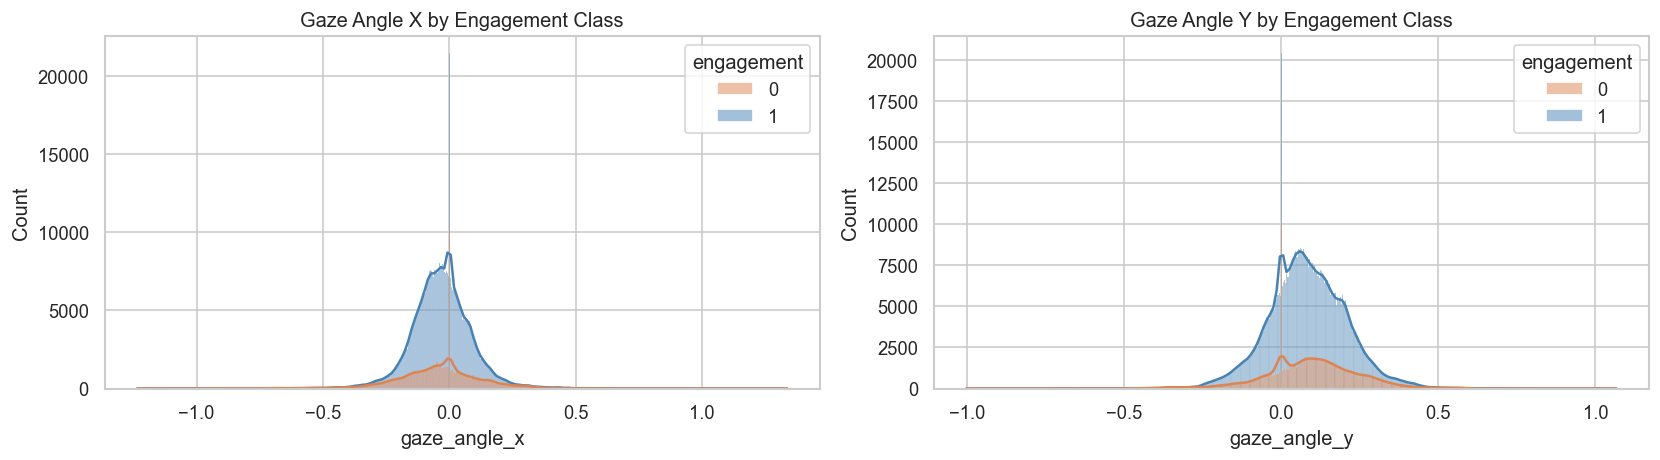


── Pose feature summary ────────────────
               mean           std
pose_Tx  -64164.597  2.109895e+07
pose_Ty  -41308.502  7.035099e+06
pose_Tz  167357.995  4.354128e+07
pose_Rx       0.037  1.920000e-01
pose_Ry       0.053  1.930000e-01
pose_Rz      -0.016  1.500000e-01


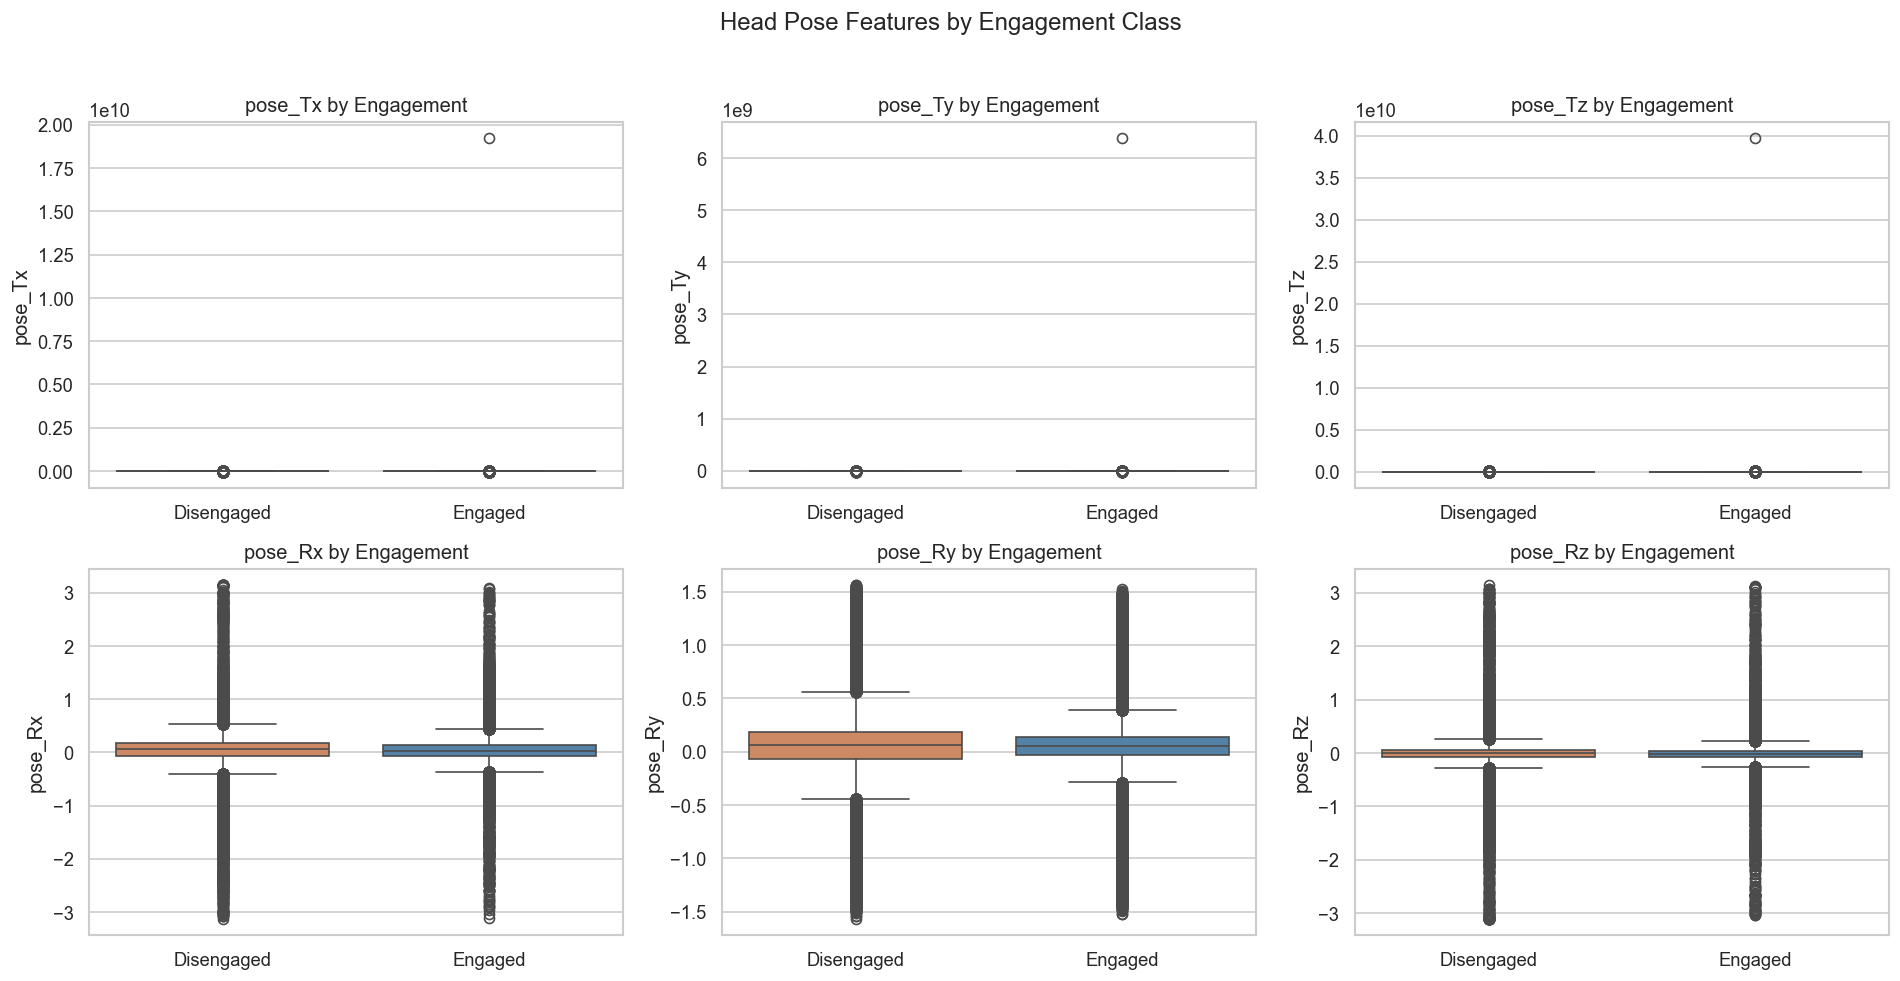

In [17]:
# ═══════════════════════════════════════════════════════
# SECTION 5: UNIVARIATE FEATURE ANALYSIS
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 5: UNIVARIATE FEATURE ANALYSIS")
print("═" * 60)

print("\n── AU Intensity (_r) summary ───────────")
print(final_df[au_r_cols].describe().round(3).T[["mean", "std", "min", "max"]])

print("\n── AU Presence (_c) activation rates ───")
au_activation = final_df[au_c_cols].mean().sort_values(ascending=False)
print(au_activation.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

au_means = final_df.groupby("engagement")[au_r_cols].mean().T
au_means.columns = ["Disengaged", "Engaged"]
au_means.plot(kind="bar", ax=axes[0], color=["#DD8452", "steelblue"])
axes[0].set_title("Mean AU Intensity by Engagement Class")
axes[0].set_xlabel("Action Unit")
axes[0].set_ylabel("Mean Intensity")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

au_activation.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("AU Presence Activation Rate")
axes[1].set_xlabel("Action Unit")
axes[1].set_ylabel("Activation Rate")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
# plt.savefig("au_analysis.png", bbox_inches="tight")
plt.show()

print("\n── Gaze feature summary ────────────────")
print(final_df[gaze_cols].describe().round(3).T[["mean", "std"]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(data=final_df, x="gaze_angle_x", hue="engagement",
             kde=True, ax=axes[0], palette=["#DD8452", "steelblue"])
axes[0].set_title("Gaze Angle X by Engagement Class")

sns.histplot(data=final_df, x="gaze_angle_y", hue="engagement",
             kde=True, ax=axes[1], palette=["#DD8452", "steelblue"])
axes[1].set_title("Gaze Angle Y by Engagement Class")

plt.tight_layout()
# plt.savefig("gaze_analysis.png", bbox_inches="tight")
plt.show()

print("\n── Pose feature summary ────────────────")
print(final_df[pose_cols].describe().round(3).T[["mean", "std"]])

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(pose_cols):
    sns.boxplot(data=final_df, x="engagement", y=col,
                ax=axes[i], palette=["#DD8452", "steelblue"])
    axes[i].set_title(f"{col} by Engagement")
    axes[i].set_xticklabels(["Disengaged", "Engaged"])
    axes[i].set_xlabel("")

plt.suptitle("Head Pose Features by Engagement Class", y=1.02)
plt.tight_layout()
# plt.savefig("pose_analysis.png", bbox_inches="tight")
plt.show()


════════════════════════════════════════════════════════════
SECTION 6: RATER AGREEMENT ANALYSIS
════════════════════════════════════════════════════════════

Overall agreement rate: 65.56%


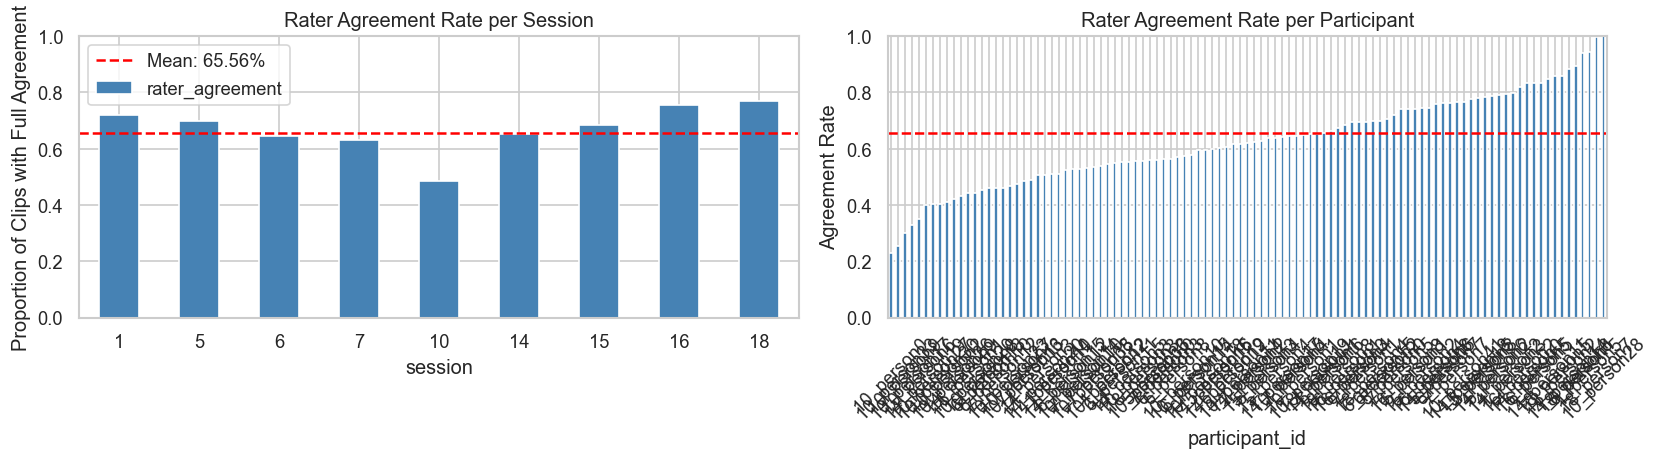

In [18]:
# ═══════════════════════════════════════════════════════
# SECTION 6: RATER AGREEMENT ANALYSIS
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 6: RATER AGREEMENT ANALYSIS")
print("═" * 60)

print(f"\nOverall agreement rate: {final_df['rater_agreement'].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

agree_by_session = final_df.groupby("session")["rater_agreement"].mean()
agree_by_session.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].axhline(final_df["rater_agreement"].mean(), color="red",
                linestyle="--",
                label=f'Mean: {final_df["rater_agreement"].mean():.2%}')
axes[0].set_title("Rater Agreement Rate per Session")
axes[0].set_ylabel("Proportion of Clips with Full Agreement")
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].tick_params(axis="x", rotation=0)

agree_by_participant = (final_df.groupby("participant_id")["rater_agreement"]
                        .mean().sort_values())
agree_by_participant.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].axhline(final_df["rater_agreement"].mean(), color="red", linestyle="--")
axes[1].set_title("Rater Agreement Rate per Participant") # low agreement means ambiguous engagement behaviour
axes[1].set_ylabel("Agreement Rate")
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis="x", rotation=45) # I know it's impossible to read the graph, but it provides a good overview. 
                                           # The actual results will be obtained via code

plt.tight_layout()
# plt.savefig("rater_agreement.png", bbox_inches="tight")
plt.show()


════════════════════════════════════════════════════════════
SECTION 7: MULTIVARIATE ANALYSIS
════════════════════════════════════════════════════════════

── AU Intensity Correlation Matrix ─────


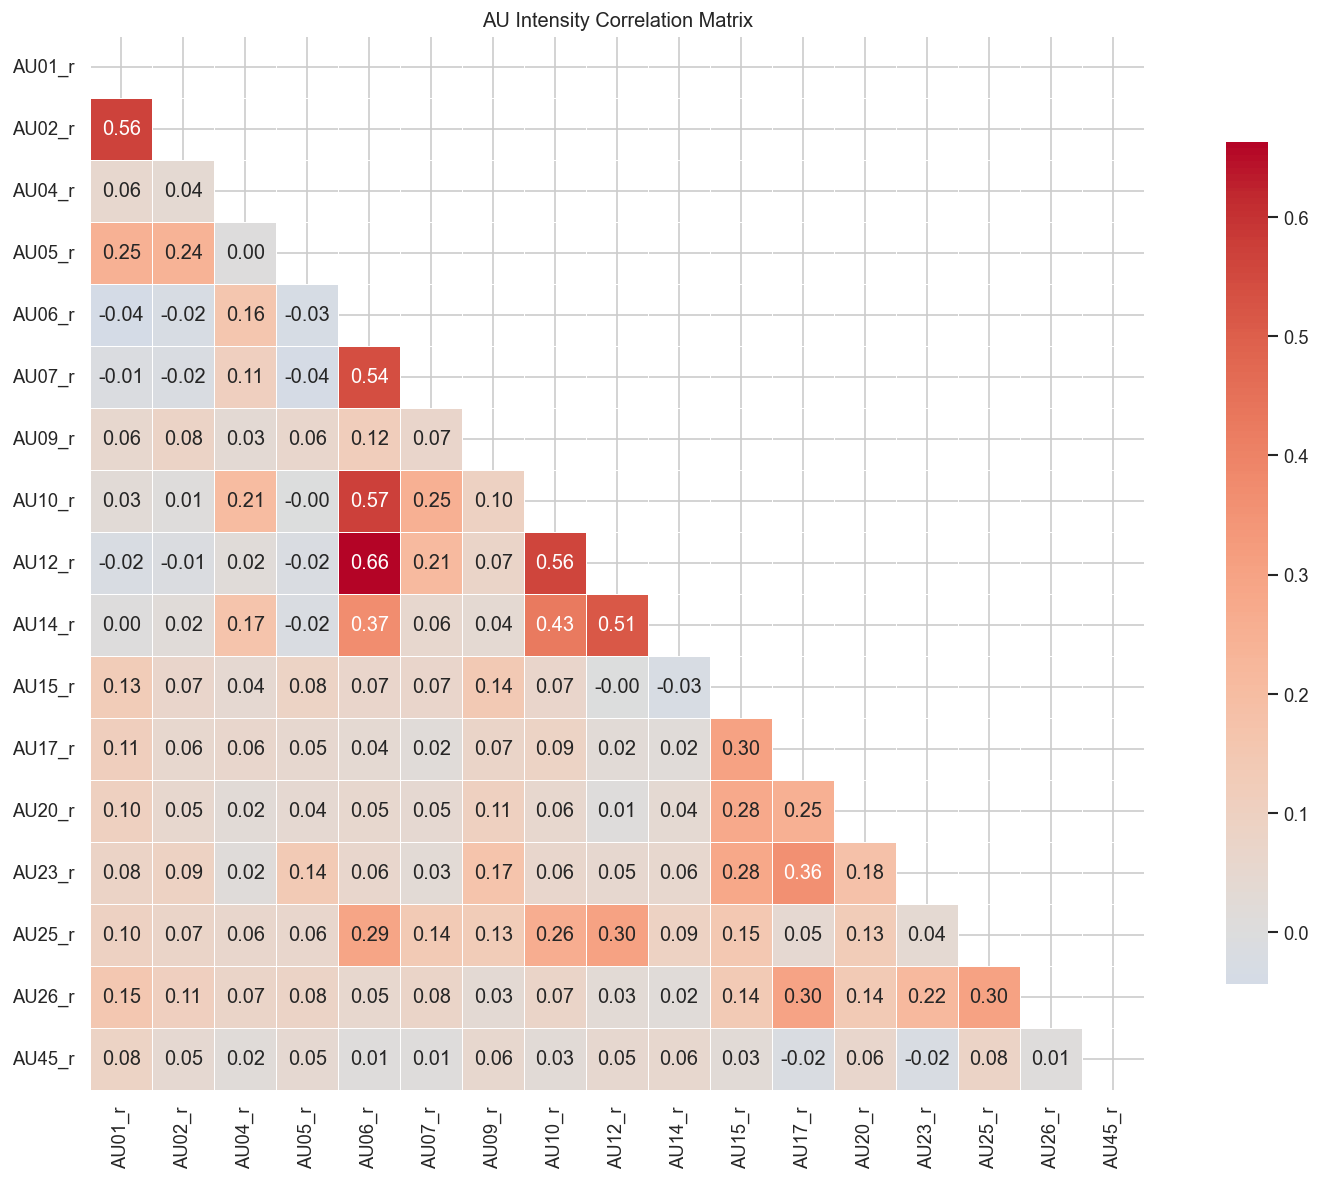


── Feature-Label Correlations ──────────
Top 15 features most correlated with engagement:
AU12_r          0.1265
AU06_r          0.1213
gaze_1_z        0.1140
gaze_0_z        0.1112
AU07_r          0.1106
AU10_r          0.0948
AU14_r          0.0653
gaze_0_y        0.0377
pose_Rz         0.0374
gaze_angle_y    0.0372
gaze_0_x        0.0370
pose_Rx         0.0361
gaze_1_y        0.0334
pose_Ry         0.0318
gaze_angle_x    0.0302
Name: engagement, dtype: float64


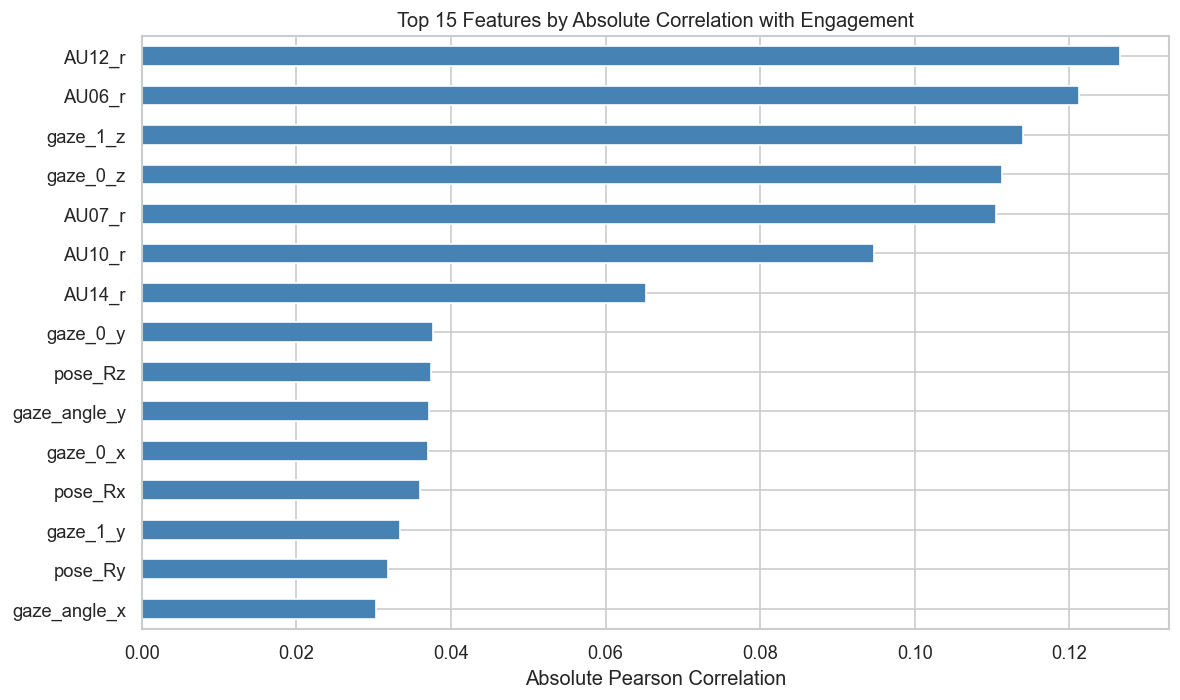


Pairplot of top 5 features: ['AU12_r', 'AU06_r', 'gaze_1_z', 'gaze_0_z', 'AU07_r']


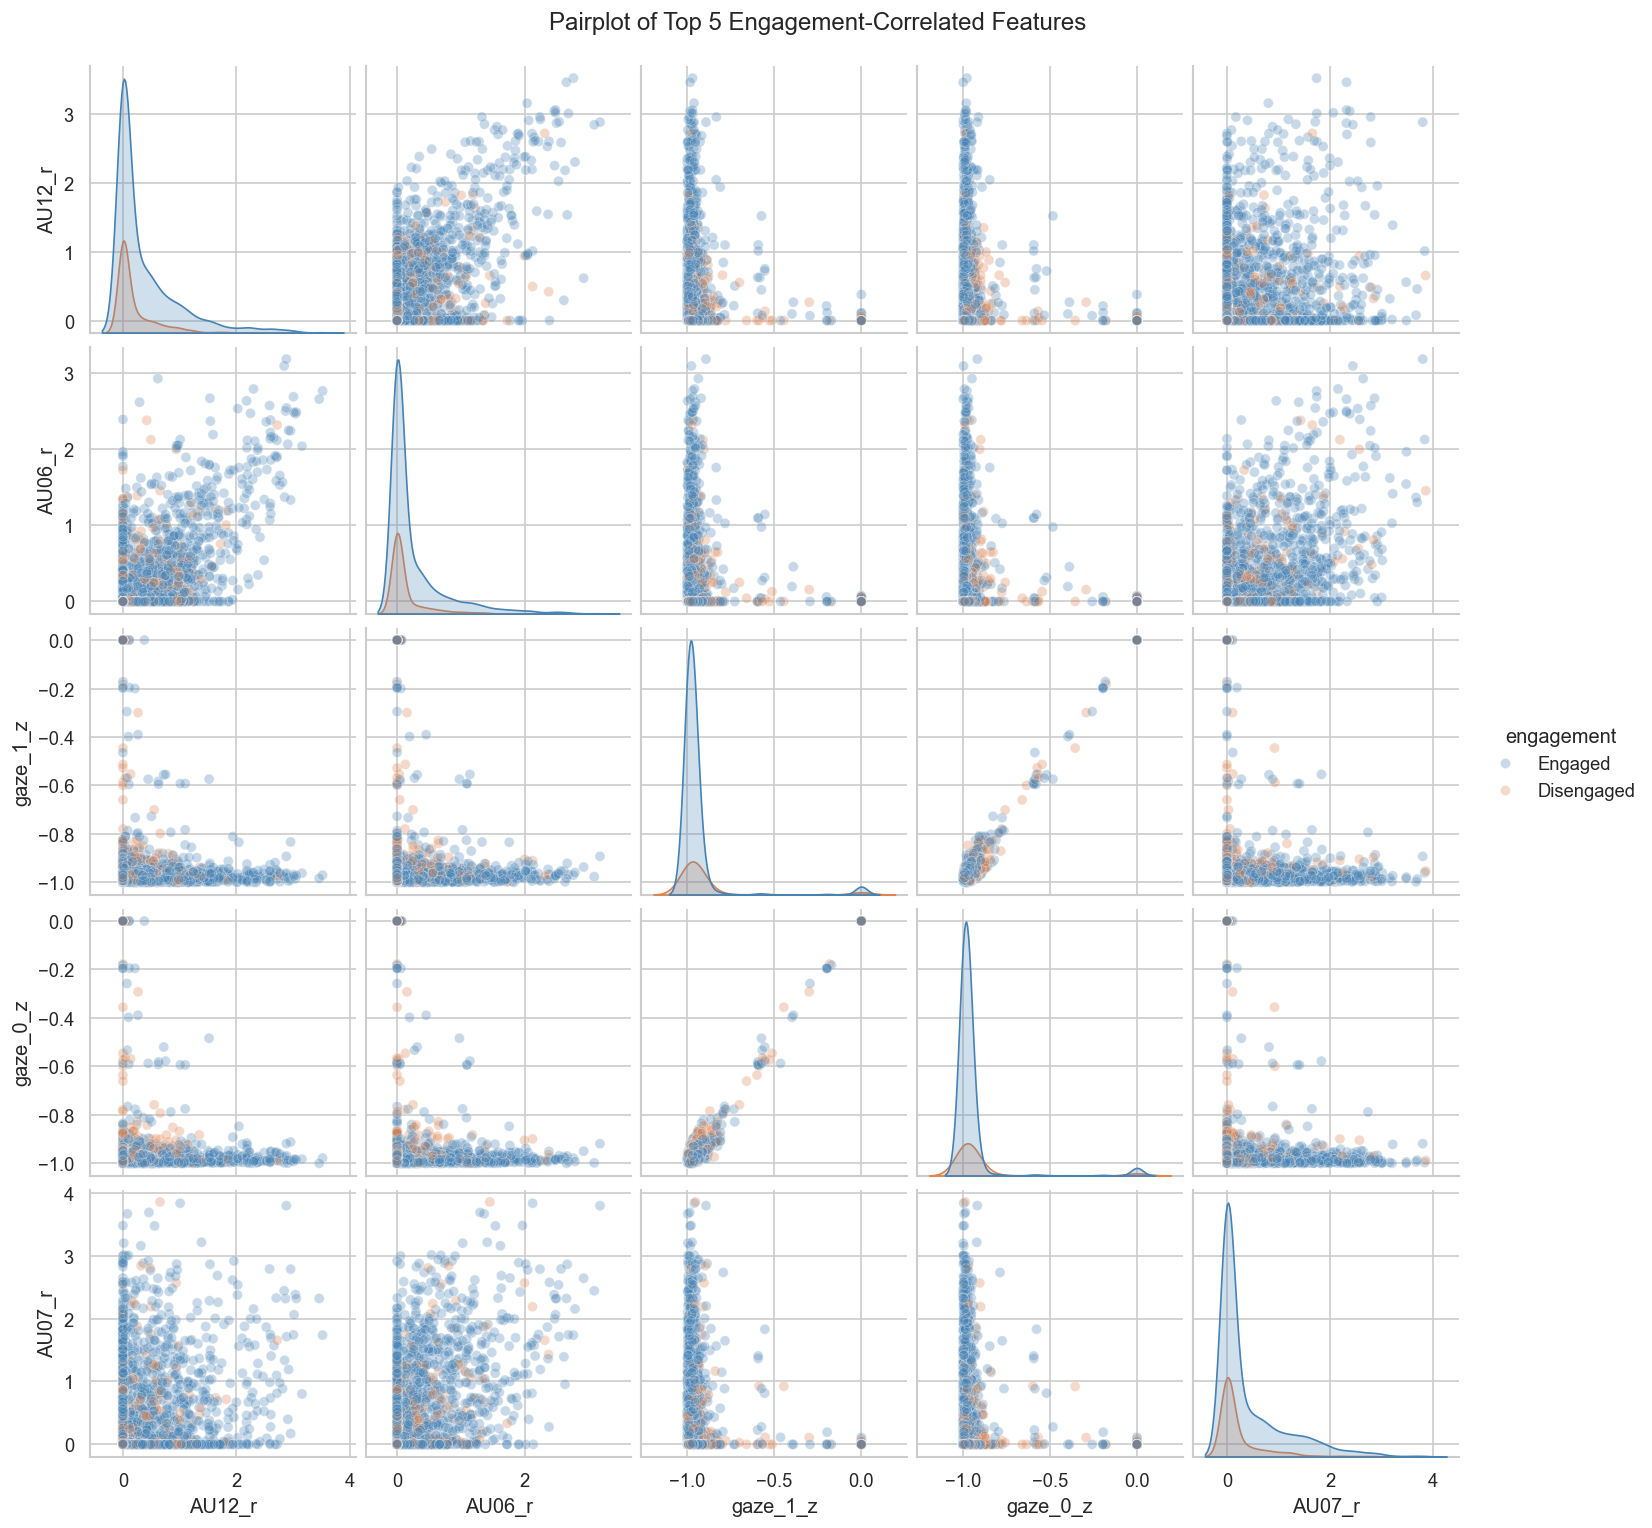

In [19]:
# ═══════════════════════════════════════════════════════
# SECTION 7: MULTIVARIATE ANALYSIS
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 7: MULTIVARIATE ANALYSIS")
print("═" * 60)

print("\n── AU Intensity Correlation Matrix ─────")
au_corr = final_df[au_r_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(au_corr, dtype=bool))
sns.heatmap(au_corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("AU Intensity Correlation Matrix")
plt.tight_layout()
# plt.savefig("au_correlation.png", bbox_inches="tight")
plt.show()

print("\n── Feature-Label Correlations ──────────")
key_features = au_r_cols + gaze_cols + pose_cols
correlations = (final_df[key_features + ["engagement"]]
                .corr()["engagement"]
                .drop("engagement"))
correlations = correlations.abs().sort_values(ascending=False)

print("Top 15 features most correlated with engagement:")
print(correlations.head(15).round(4))

fig, ax = plt.subplots(figsize=(10, 6))
correlations.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Top 15 Features by Absolute Correlation with Engagement")
ax.set_xlabel("Absolute Pearson Correlation")
plt.tight_layout()
# plt.savefig("feature_label_correlation.png", bbox_inches="tight")
plt.show()

#
top_features = correlations.head(5).index.tolist()
print(f"\nPairplot of top 5 features: {top_features}") # on the diagonal is the smoothed density curve of the feature's distribution split by class
                                                       # since there's no point in plotting the correlation of a feat against itself

pairplot_df = final_df[top_features + ["engagement"]].sample(
    min(3000, len(final_df)), random_state=42) # sampled on 3000 random rows because the dataset is too big to do it on that
pairplot_df["engagement"] = pairplot_df["engagement"].map(
    {0: "Disengaged", 1: "Engaged"})

g = sns.pairplot(pairplot_df, hue="engagement",
                 palette={"Disengaged": "#DD8452", "Engaged": "steelblue"},
                 plot_kws={"alpha": 0.3}, diag_kind="kde")
g.fig.suptitle("Pairplot of Top 5 Engagement-Correlated Features", y=1.02)
# plt.savefig("pairplot.png", bbox_inches="tight")
plt.show()


════════════════════════════════════════════════════════════
SECTION 8: OUTLIER DETECTION
════════════════════════════════════════════════════════════
Timesteps with at least one feature > 3 std: 225,712 (27.11%)
Outlier class distribution:
engagement
1    0.772
0    0.228
Name: proportion, dtype: float64

Features with most outliers:
gaze_0_z    27897
gaze_1_z    27839
AU06_r      22642
AU12_r      20840
AU45_r      20401
AU25_r      19882
AU23_r      19145
AU04_r      18383
AU07_r      18296
AU05_r      18253
dtype: int64


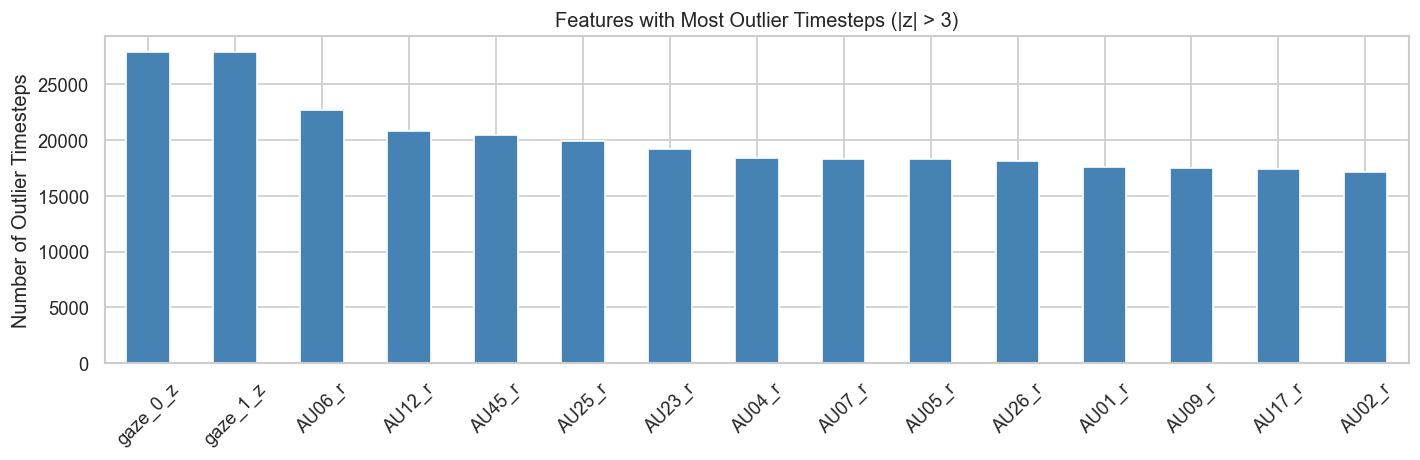

In [20]:
# ═══════════════════════════════════════════════════════
# SECTION 8: OUTLIER DETECTION
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 8: OUTLIER DETECTION")
print("═" * 60)

key_cols = au_r_cols + pose_cols + gaze_cols
z_scores = np.abs(stats.zscore(final_df[key_cols].fillna(0)))
outlier_mask = (z_scores > 3).any(axis=1)

print(f"Timesteps with at least one feature > 3 std: "
      f"{outlier_mask.sum():,} ({outlier_mask.mean():.2%})")
print(f"Outlier class distribution:")
print(final_df[outlier_mask]["engagement"].value_counts(normalize=True).round(3))

outlier_counts = pd.Series(
    (z_scores > 3).sum(axis=0),
    index=key_cols
).sort_values(ascending=False)
print(f"\nFeatures with most outliers:")
print(outlier_counts.head(10))

fig, ax = plt.subplots(figsize=(12, 4))
outlier_counts.head(15).plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Features with Most Outlier Timesteps (|z| > 3)")
ax.set_ylabel("Number of Outlier Timesteps")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
# plt.savefig("outliers.png", bbox_inches="tight")
plt.show()


════════════════════════════════════════════════════════════
SECTION 9: TEMPORAL ANALYSIS
════════════════════════════════════════════════════════════


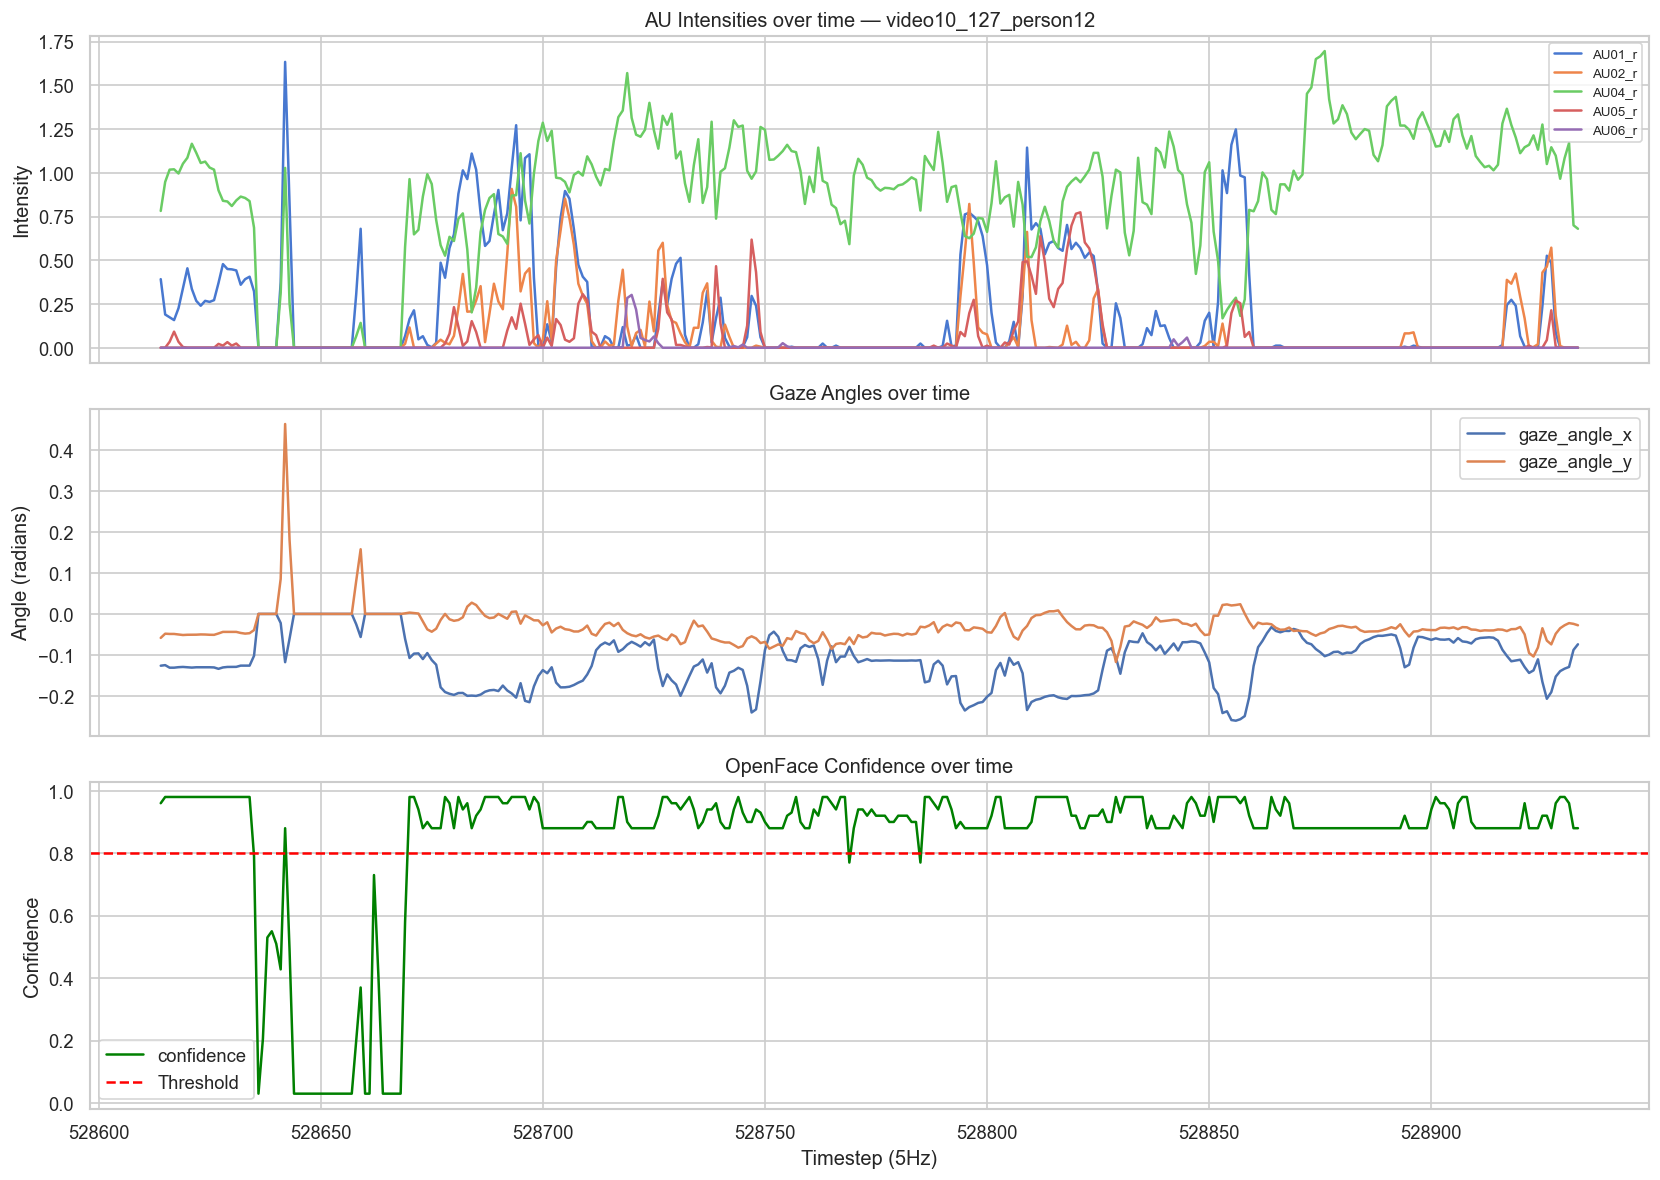

In [21]:
# ═══════════════════════════════════════════════════════
# SECTION 9: TEMPORAL ANALYSIS
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 9: TEMPORAL ANALYSIS")
print("═" * 60)

example_clip = final_df["clip_id"].value_counts().index[0]
clip_example = (final_df[final_df["clip_id"] == example_clip]
                .sort_values("timestep"))

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

clip_example[au_r_cols[:5]].plot(ax=axes[0])
axes[0].set_title(f"AU Intensities over time — {example_clip}")
axes[0].set_ylabel("Intensity")
axes[0].legend(loc="upper right", fontsize=8)

clip_example[["gaze_angle_x", "gaze_angle_y"]].plot(
    ax=axes[1], color=["#4C72B0", "#DD8452"])
axes[1].set_title("Gaze Angles over time")
axes[1].set_ylabel("Angle (radians)")

clip_example["confidence"].plot(ax=axes[2], color="green")
axes[2].axhline(0.8, color="red", linestyle="--", label="Threshold")
axes[2].set_title("OpenFace Confidence over time")
axes[2].set_ylabel("Confidence")
axes[2].set_xlabel("Timestep (5Hz)")
axes[2].legend()

plt.tight_layout()
# plt.savefig("temporal_analysis.png", bbox_inches="tight")
plt.show()

In [22]:
# ═══════════════════════════════════════════════════════
# SECTION 10: EDA SUMMARY
# ═══════════════════════════════════════════════════════
print("\n" + "═" * 60)
print("SECTION 10: EDA SUMMARY")
print("═" * 60)

print(f"""
Key findings:
─────────────────────────────────────────────────────
Dataset:
  • {final_df['clip_id'].nunique():,} clips across {final_df['session'].nunique()} sessions
  • {final_df['participant_id'].nunique()} unique participants
  • {len(final_df):,} timesteps after 5Hz downsampling
  • {final_df.shape[1]} total columns

Class balance:
  • Engaged:    {ts_pct.get(1, 0):.2%} of timesteps
  • Disengaged: {ts_pct.get(0, 0):.2%} of timesteps
  • Baseline accuracy: {majority_class:.2%}

Tracking quality:
  • Mean confidence: {final_df['confidence'].mean():.3f}
  • Low confidence timesteps: {(final_df['confidence'] < 0.8).mean():.2%}

Rater agreement:
  • Overall agreement rate: {final_df['rater_agreement'].mean():.2%}

Top 5 features correlated with engagement:
  {', '.join(correlations.head(5).index.tolist())}
─────────────────────────────────────────────────────
""")


════════════════════════════════════════════════════════════
SECTION 10: EDA SUMMARY
════════════════════════════════════════════════════════════

Key findings:
─────────────────────────────────────────────────────
Dataset:
  • 12,197 clips across 9 sessions
  • 103 unique participants
  • 832,587 timesteps after 5Hz downsampling
  • 721 total columns

Class balance:
  • Engaged:    79.86% of timesteps
  • Disengaged: 20.14% of timesteps
  • Baseline accuracy: 80.05%

Tracking quality:
  • Mean confidence: 0.926
  • Low confidence timesteps: 4.15%

Rater agreement:
  • Overall agreement rate: 65.56%

Top 5 features correlated with engagement:
  AU12_r, AU06_r, gaze_1_z, gaze_0_z, AU07_r
─────────────────────────────────────────────────────



### Very Basic Logistic Regression Baseline Model

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score)

In [24]:
##########################################
# SETUP
##########################################

# using AU, gaze, and pose features only for this example. Using landmark features here would make it too complex
feature_cols = au_r_cols + au_c_cols + gaze_cols + pose_cols

X = final_df[feature_cols].values
y = final_df["engagement"].values

##########################################
# TRAIN/TEST SPLIT 
# on participants
##########################################
participants = final_df["participant_id"].unique()
np.random.seed(42)
np.random.shuffle(participants)

split_idx      = int(len(participants) * 0.8)
train_participants = participants[:split_idx]
test_participants  = participants[split_idx:]

train_mask = final_df["participant_id"].isin(train_participants)
test_mask  = final_df["participant_id"].isin(test_participants)

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f"Train: {X_train.shape[0]:,} timesteps, {len(train_participants)} participants")
print(f"Test:  {X_test.shape[0]:,} timesteps,  {len(test_participants)} participants")
print(f"Train class balance: {y_train.mean():.2%} engaged")
print(f"Test class balance:  {y_test.mean():.2%} engaged")

Train: 650,528 timesteps, 82 participants
Test:  182,059 timesteps,  21 participants
Train class balance: 80.24% engaged
Test class balance:  78.49% engaged


In [25]:
##########################################
# SCALE FEATURES
##########################################
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

##########################################
# MAJORITY CLASS BASELINE
##########################################
majority_class    = int(y_train.mean() >= 0.5)
majority_preds    = np.full_like(y_test, majority_class)
majority_accuracy = accuracy_score(y_test, majority_preds)

print(f"\n── Majority Class Baseline ─────────────")
print(f"Always predicts: {majority_class} ({'Engaged' if majority_class == 1 else 'Disengaged'})")
print(f"Accuracy: {majority_accuracy:.4f}")


── Majority Class Baseline ─────────────
Always predicts: 1 (Engaged)
Accuracy: 0.7849


In [26]:
##########################################
# LOGISTIC REGRESSION
##########################################
lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",  # to handle class imbalance
    random_state=42
)
lr.fit(X_train, y_train)

y_pred  = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

##########################################
# RESULTS
##########################################
print(f"\n── Logistic Regression Results ─────────")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}  "
      f"(baseline: {majority_accuracy:.4f})")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["Disengaged", "Engaged"]))


── Logistic Regression Results ─────────
Accuracy:  0.5923  (baseline: 0.7849)
ROC-AUC:   0.6340

Classification Report:
              precision    recall  f1-score   support

  Disengaged       0.29      0.60      0.39     39166
     Engaged       0.84      0.59      0.69    142893

    accuracy                           0.59    182059
   macro avg       0.56      0.59      0.54    182059
weighted avg       0.72      0.59      0.63    182059




── Top 15 Most Important Features ─────
     feature  coefficient
gaze_angle_y     3.304075
gaze_angle_x     3.246569
    gaze_0_x     1.905104
    gaze_1_y     1.663090
    gaze_0_y     1.534576
    gaze_1_x     1.290816
      AU14_c     0.314127
      AU12_r     0.215926
      AU07_r     0.214498
    gaze_0_z     0.214388
      AU14_r     0.191981
      AU06_c     0.180839
      AU10_r     0.129003
      AU10_c     0.128002
      AU05_c     0.093229


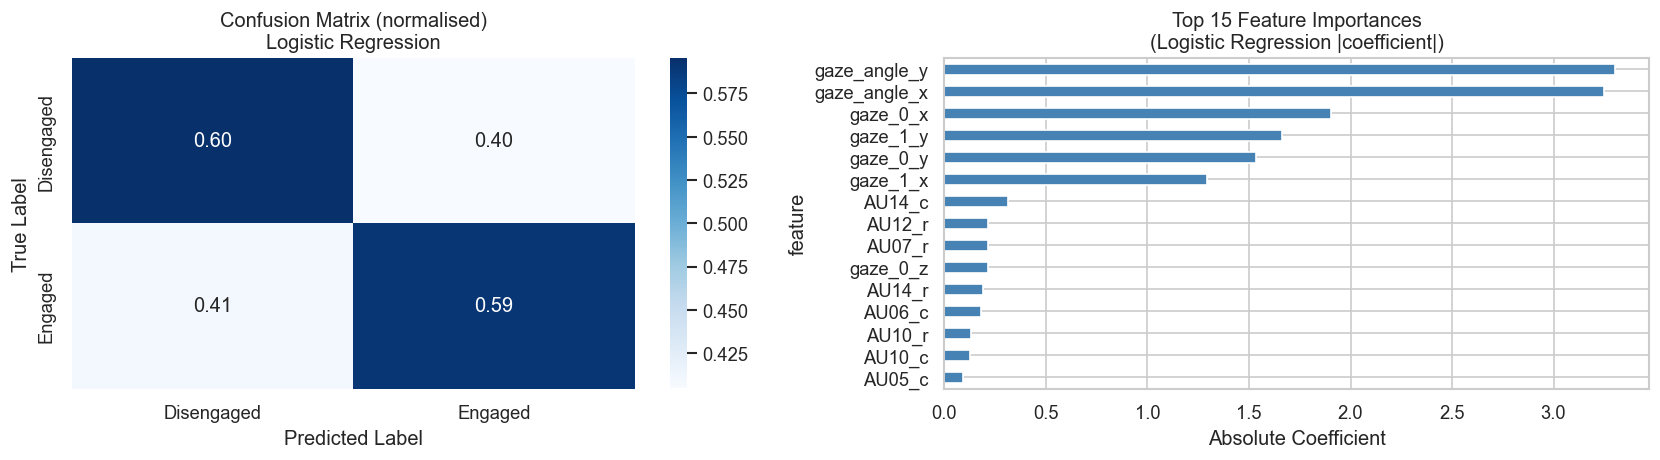

In [27]:
##########################################
# CONFUSION MATRIX
##########################################
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

cm = confusion_matrix(y_test, y_pred, normalize="true")
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=["Disengaged", "Engaged"],
            yticklabels=["Disengaged", "Engaged"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix (normalised)\nLogistic Regression")
axes[0].set_ylabel("True Label")
axes[0].set_xlabel("Predicted Label")

##########################################
# FEATURE IMPORTANCE
# coefficient magnitude
##########################################
coef_df = pd.DataFrame({
    "feature":     feature_cols,
    "coefficient": np.abs(lr.coef_[0])
}).sort_values("coefficient", ascending=False)

print(f"\n── Top 15 Most Important Features ─────")
print(coef_df.head(15).to_string(index=False))

coef_df.head(15).sort_values("coefficient").plot(
    kind="barh", x="feature", y="coefficient",
    ax=axes[1], color="steelblue", legend=False)
axes[1].set_title("Top 15 Feature Importances\n(Logistic Regression |coefficient|)")
axes[1].set_xlabel("Absolute Coefficient")

plt.tight_layout()
# plt.savefig("baseline_results.png", bbox_inches="tight")
plt.show()


── Per-Participant Performance ─────────
                accuracy  n_timesteps  prop_engaged
participant_id                                     
10_person28        0.278           72         0.000
6_person9          0.370        15089         0.810
10_person8         0.387          775         0.795
16_person4         0.398         8939         0.854
16_person8         0.429        11738         0.764
10_person10        0.454         5735         0.816
1_person2          0.480         9356         0.775
6_person3          0.493        14905         0.753
10_person9         0.498         7363         0.575
6_person13         0.541        11660         0.520
1_person4          0.547         1922         0.803
14_person11        0.550         4384         0.879
14_person9         0.563         3575         0.648
14_person19        0.590         4121         0.655
10_person33        0.597         1120         0.321
15_person4         0.689        12678         0.754
15_person3         0.7

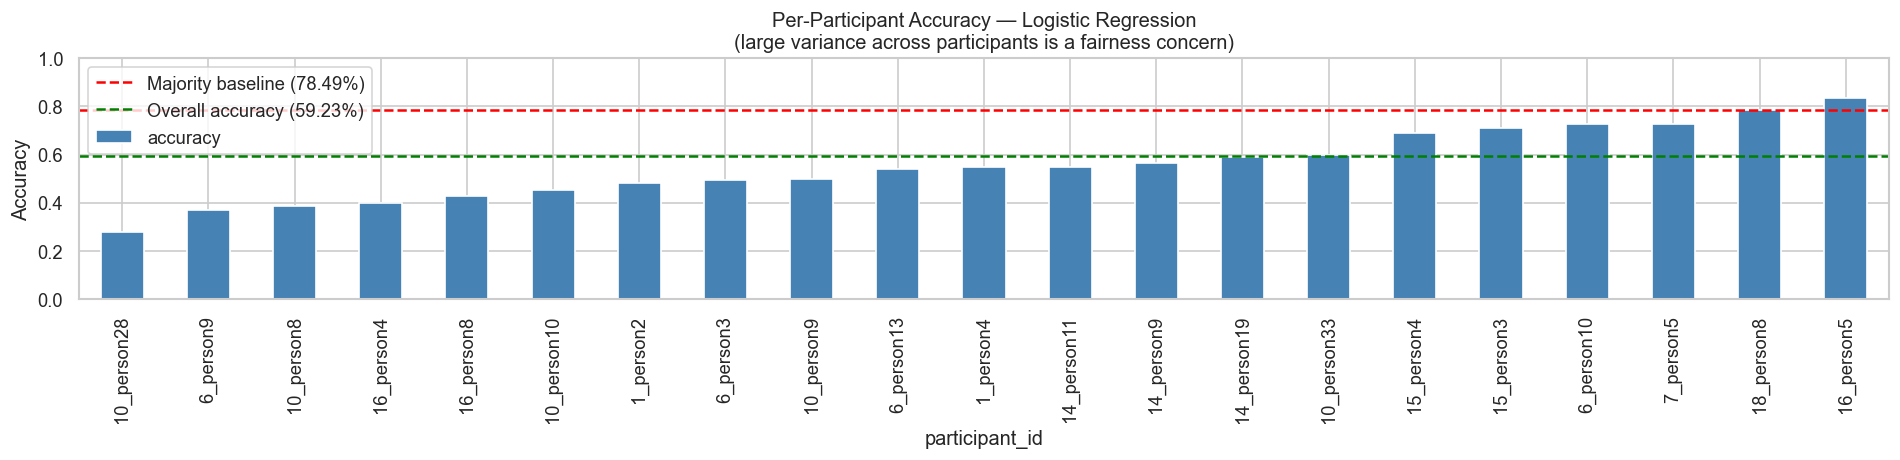

In [28]:
##########################################
# FAIRNESS BREAKDOWN
# performance per participant
##########################################
print(f"\n── Per-Participant Performance ─────────")

test_df = final_df[test_mask].copy()
test_df["y_pred"]  = y_pred
test_df["y_proba"] = y_proba
test_df["correct"] = (test_df["y_pred"] == test_df["engagement"]).astype(int)

participant_perf = (test_df.groupby("participant_id")
                   .agg(
                       accuracy    = ("correct", "mean"),
                       n_timesteps = ("correct", "count"),
                       prop_engaged = ("engagement", "mean")
                   )
                   .sort_values("accuracy"))

print(participant_perf.round(3).to_string())

fig, ax = plt.subplots(figsize=(16, 4))
participant_perf["accuracy"].plot(kind="bar", ax=ax, color="steelblue")
ax.axhline(majority_accuracy, color="red", linestyle="--",
           label=f"Majority baseline ({majority_accuracy:.2%})")
ax.axhline(accuracy_score(y_test, y_pred), color="green", linestyle="--",
           label=f"Overall accuracy ({accuracy_score(y_test, y_pred):.2%})")
ax.set_title("Per-Participant Accuracy — Logistic Regression\n"
             "(large variance across participants is a fairness concern)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
# plt.savefig("baseline_fairness.png", bbox_inches="tight")
plt.show()

# Extra Dataset

Not sure if this applies to me exactly since it talks a lot about internship data, but as asked for in the EDA assignment on Canvas, the extra dataset I have is the DAiSEE dataset which can be found on Kaggle here: https://www.kaggle.com/datasets/olgaparfenova/daisee

It is a dataset designed for engagement detection in online environments, similar to CMOSE and will serve as a direction to go if something goes wrong in modelling.

GitHub link: https://github.com/AranLos/EngageFair

In [29]:
# Save
final_df.to_parquet(r"C:\Users\super\Desktop\Data Thesis\final_df.parquet", index=False)